# Proyecto Final — Módulo 2
## Predicción del equipo ganador en partidas profesionales de Dota 2
### Versión PySpark (Spark MLlib)

**Autor:** Fuentes Saldaña Juan · Grupo G38
**Dataset:** [Dota 2 Matches (Pro Leagues)](https://www.kaggle.com/datasets/darianogina/dota-2-matches-pro-leagues)

Esta es la versión en PySpark del proyecto, usando `pyspark.sql` para el procesamiento de datos
y `pyspark.ml` para el modelado (Pipeline, VectorAssembler, StandardScaler, StringIndexer/OneHotEncoder
y los clasificadores `LogisticRegression`, `RandomForestClassifier` y `GBTClassifier`).

> **Nota sobre el tamaño de los datos:** este dataset (~194 mil filas) es pequeño para el caso de uso
> típico de Spark, que está diseñado para datos distribuidos en clústeres (millones/miles de millones
> de filas que no caben en una sola máquina). Para este volumen, pandas + scikit-learn suele ser más
> rápido en una sola máquina. Esta versión se incluye con fines de aprendizaje de la herramienta y
> porque el pipeline de Spark ML es directamente escalable si el dataset creciera.

## 1. Crear la sesión de Spark

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = (SparkSession.builder
         .appName("Dota2WinPrediction")
         .config("spark.driver.memory", "3g")
         .config("spark.sql.shuffle.partitions", "8")
         # Necesario: el parquet de Kaggle guarda timestamps en nanosegundos,
         # que Spark no soporta leer por defecto.
         .config("spark.sql.legacy.parquet.nanosAsLong", "true")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")
spark

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/09/21 13:53:46 WARN Utils: Your hostname, MacBook-Air-de-Cry.local, resolves to a loopback address: 127.0.0.1; using 192.168.100.64 instead (on interface en0)
26/09/21 13:53:46 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/21 13:53:48 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## 2. Descarga del dataset

Igual que en la versión pandas, se intenta descargar con `kagglehub` y, si falla (por ejemplo, sin
credenciales de Kaggle configuradas), se usa una copia local de respaldo.

In [2]:
import glob, os

DATA_PATH = None
try:
    import kagglehub
    path = kagglehub.dataset_download("darianogina/dota-2-matches-pro-leagues")
    print("Path to dataset files:", path)
    parquet_files = glob.glob(os.path.join(path, "*.parquet"))
    if parquet_files:
        DATA_PATH = parquet_files[0]
except Exception as e:
    print("No se pudo descargar con kagglehub:", e)

if DATA_PATH is None:
    fallback = "./data/dota2_matches.parquet"
    if os.path.exists(fallback):
        print("Usando copia local de respaldo:", fallback)
        DATA_PATH = fallback
    else:
        raise FileNotFoundError(
            "No se encontró el dataset. Configura tus credenciales de Kaggle o coloca "
            "dota2_matches.parquet en ./data/"
        )

print("Archivo de datos a usar:", DATA_PATH)

No se pudo descargar con kagglehub: No module named 'kagglehub'
Usando copia local de respaldo: ./data/dota2_matches.parquet
Archivo de datos a usar: ./data/dota2_matches.parquet


## 3. Carga y limpieza de datos (Spark DataFrame)

In [3]:
df = spark.read.parquet(DATA_PATH)
print("Filas:", df.count(), "Columnas:", len(df.columns))

df = df.dropDuplicates(["match_id"])
df = df.dropna(subset=["winner_id", "radiant_team_id", "dire_team_id", "match_duration_seconds"])
df = df.filter(F.col("match_duration_seconds") >= 300)  # descarta remakes/abandonos
print("Filas tras limpieza:", df.count())

df = df.withColumn("radiant_win", (F.col("winner_id") == F.col("radiant_team_id")).cast("int"))
df.groupBy("radiant_win").count().show()

Filas: 193773 Columnas: 130
Filas tras limpieza: 191736
+-----------+-----+
|radiant_win|count|
+-----------+-----+
|          1|98188|
|          0|93548|
+-----------+-----+



## 4. Ingeniería de variables (Spark SQL)

In [4]:
rad_k = [f"radiant_player_{i}_kills" for i in range(1, 6)]
rad_d = [f"radiant_player_{i}_deaths" for i in range(1, 6)]
rad_a = [f"radiant_player_{i}_assists" for i in range(1, 6)]
rad_n = [f"radiant_player_{i}_networth" for i in range(1, 6)]
dire_k = [f"dire_player_{i}_kills" for i in range(1, 6)]
dire_d = [f"dire_player_{i}_deaths" for i in range(1, 6)]
dire_a = [f"dire_player_{i}_assists" for i in range(1, 6)]
dire_n = [f"dire_player_{i}_networth" for i in range(1, 6)]

def sum_cols(cols):
    e = F.col(cols[0])
    for c in cols[1:]:
        e = e + F.col(c)
    return e

df = (df
      .withColumn("radiant_kills_total", sum_cols(rad_k))
      .withColumn("dire_kills_total", sum_cols(dire_k))
      .withColumn("radiant_deaths_total", sum_cols(rad_d))
      .withColumn("dire_deaths_total", sum_cols(dire_d))
      .withColumn("radiant_assists_total", sum_cols(rad_a))
      .withColumn("dire_assists_total", sum_cols(dire_a))
      .withColumn("radiant_networth_total", sum_cols(rad_n))
      .withColumn("dire_networth_total", sum_cols(dire_n)))

df = (df
      .withColumn("kills_diff", F.col("radiant_kills_total") - F.col("dire_kills_total"))
      .withColumn("deaths_diff", F.col("radiant_deaths_total") - F.col("dire_deaths_total"))
      .withColumn("assists_diff", F.col("radiant_assists_total") - F.col("dire_assists_total"))
      .withColumn("networth_diff", F.col("radiant_networth_total") - F.col("dire_networth_total"))
      .withColumn("networth_ratio", F.col("radiant_networth_total") /
                  F.when(F.col("dire_networth_total") == 0, None).otherwise(F.col("dire_networth_total")))
      .withColumn("kda_radiant", (F.col("radiant_kills_total") + F.col("radiant_assists_total")) /
                  F.when(F.col("radiant_deaths_total") == 0, 1).otherwise(F.col("radiant_deaths_total")))
      .withColumn("kda_dire", (F.col("dire_kills_total") + F.col("dire_assists_total")) /
                  F.when(F.col("dire_deaths_total") == 0, 1).otherwise(F.col("dire_deaths_total")))
      .withColumn("kda_diff", F.col("kda_radiant") - F.col("kda_dire")))

numeric_features = ["match_duration_seconds", "first_blood_time_seconds",
                     "kills_diff", "assists_diff", "networth_diff", "networth_ratio", "kda_diff"]
categorical_features = ["league_tier", "league_region", "series_type"]
target = "radiant_win"

data = df.select(*(numeric_features + ["deaths_diff"] + categorical_features + [target])).dropna()
print("Dataset de modelado:", data.count(), "filas")

Dataset de modelado: 102743 filas


## 5. Análisis exploratorio

Para graficar convertimos únicamente los agregados (ya reducidos) a pandas — nunca el dataset completo.

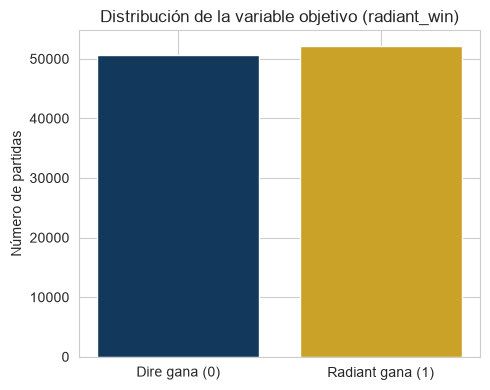

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
NAVY, GOLD = '#12395B', '#C9A227'

balance_pd = data.groupBy(target).count().orderBy(target).toPandas()
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Dire gana (0)', 'Radiant gana (1)'], balance_pd['count'], color=[NAVY, GOLD])
ax.set_ylabel('Número de partidas')
ax.set_title('Distribución de la variable objetivo (radiant_win)')
plt.tight_layout(); plt.show()

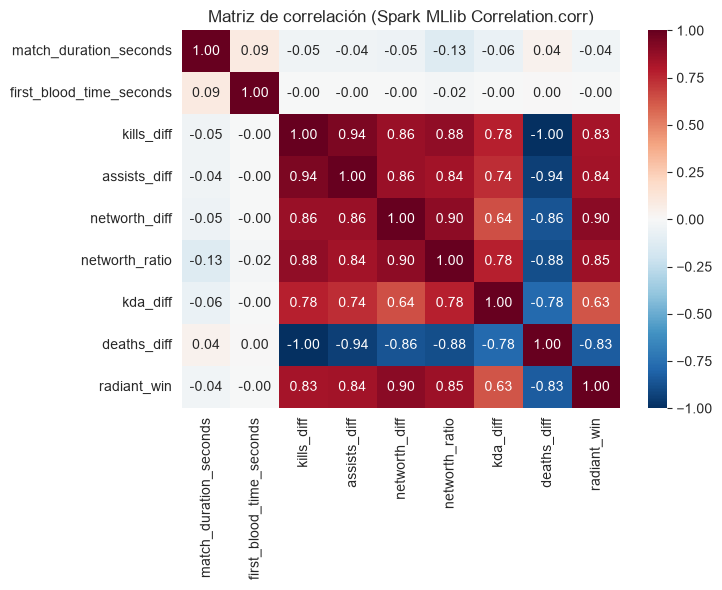

radiant_win                 1.000000
networth_diff               0.904890
networth_ratio              0.852760
assists_diff                0.840421
kills_diff                  0.829748
kda_diff                    0.632174
first_blood_time_seconds   -0.002530
match_duration_seconds     -0.038062
deaths_diff                -0.830303
Name: radiant_win, dtype: float64

>> deaths_diff con r=-1.00 respecto a kills_diff -> se excluye del modelado por colinealidad.


In [6]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation
import pandas as pd

corr_cols = numeric_features + ['deaths_diff', target]
assembler_corr = VectorAssembler(inputCols=corr_cols, outputCol="corr_features")
vec_df = assembler_corr.transform(data).select("corr_features")
corr_matrix = Correlation.corr(vec_df, "corr_features").head()[0].toArray()
corr_pd = pd.DataFrame(corr_matrix, index=corr_cols, columns=corr_cols)

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(corr_pd, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Matriz de correlación (Spark MLlib Correlation.corr)')
plt.tight_layout(); plt.show()

print(corr_pd[target].sort_values(ascending=False))
print("\n>> deaths_diff con r=-1.00 respecto a kills_diff -> se excluye del modelado por colinealidad.")

## 6. Procesamiento: muestra, partición y pipeline de features

In [7]:
# Muestra estratificada aprox. (Spark .sample no garantiza tamaño exacto, se ajusta la fracción)
total = data.count()
sample_frac = min(1.0, 30000 / total)
data_s = data.sample(withReplacement=False, fraction=sample_frac, seed=42)
print("Tamaño de la muestra:", data_s.count())

train, test = data_s.randomSplit([0.8, 0.2], seed=42)
print("Train:", train.count(), "Test:", test.count())
train.cache(); test.cache()

Tamaño de la muestra: 29969


Train: 24128 Test: 5841


DataFrame[match_duration_seconds: int, first_blood_time_seconds: int, kills_diff: smallint, assists_diff: smallint, networth_diff: bigint, networth_ratio: double, kda_diff: double, deaths_diff: smallint, league_tier: string, league_region: string, series_type: string, radiant_win: int]

In [8]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml import Pipeline

indexers = [StringIndexer(inputCol=c, outputCol=c + "_idx", handleInvalid="keep") for c in categorical_features]
encoders = [OneHotEncoder(inputCol=c + "_idx", outputCol=c + "_ohe") for c in categorical_features]

num_assembler = VectorAssembler(inputCols=numeric_features, outputCol="num_features")
scaler = StandardScaler(inputCol="num_features", outputCol="num_features_scaled", withMean=True, withStd=True)

final_assembler = VectorAssembler(
    inputCols=["num_features_scaled"] + [c + "_ohe" for c in categorical_features],
    outputCol="features"
)

preprocessing_stages = indexers + encoders + [num_assembler, scaler, final_assembler]

## 7. Modelado: 3 clasificadores de `pyspark.ml`

Se usan los equivalentes directos de los modelos de scikit-learn:
`LogisticRegression`, `RandomForestClassifier` y `GBTClassifier` (Gradient-Boosted Trees).
Los grids de hiperparámetros son deliberadamente pequeños para mantener el tiempo de cómputo
razonable en un entorno de un solo nodo.

In [9]:
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator, TrainValidationSplit
import time, json

evaluator_auc = BinaryClassificationEvaluator(labelCol=target, metricName="areaUnderROC")
evaluator_acc = MulticlassClassificationEvaluator(labelCol=target, metricName="accuracy")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol=target, metricName="f1")
evaluator_prec = MulticlassClassificationEvaluator(labelCol=target, metricName="weightedPrecision")
evaluator_rec = MulticlassClassificationEvaluator(labelCol=target, metricName="weightedRecall")

results = []
best_models = {}

def evaluate(name, model, best_params, fit_time):
    pred_train = model.transform(train)
    pred_test = model.transform(test)
    row = {
        'modelo': name,
        'mejores_hiperparametros': json.dumps(best_params),
        'accuracy_train': evaluator_acc.evaluate(pred_train),
        'accuracy_test': evaluator_acc.evaluate(pred_test),
        'precision_test': evaluator_prec.evaluate(pred_test),
        'recall_test': evaluator_rec.evaluate(pred_test),
        'f1_test': evaluator_f1.evaluate(pred_test),
        'roc_auc_test': evaluator_auc.evaluate(pred_test),
        'tiempo_ajuste_s': fit_time,
    }
    results.append(row)
    best_models[name] = model
    print(row)
    return row

In [10]:
# 1) Regresión Logística (con validación cruzada, k=3)
t0 = time.time()
lr = LogisticRegression(featuresCol="features", labelCol=target, maxIter=100)
pipe_lr = Pipeline(stages=preprocessing_stages + [lr])
grid_lr = ParamGridBuilder().addGrid(lr.regParam, [0.01, 0.1]).addGrid(lr.elasticNetParam, [0.0]).build()
cv_lr = CrossValidator(estimator=pipe_lr, estimatorParamMaps=grid_lr, evaluator=evaluator_auc,
                        numFolds=3, parallelism=1, seed=42)
cvmodel_lr = cv_lr.fit(train)
best_lr = cvmodel_lr.bestModel
best_params_lr = {"regParam": best_lr.stages[-1].getRegParam()}
evaluate("Regresión Logística", best_lr, best_params_lr, time.time() - t0)

{'modelo': 'Regresión Logística', 'mejores_hiperparametros': '{"regParam": 0.01}', 'accuracy_train': 0.9863643899204244, 'accuracy_test': 0.9859613079952063, 'precision_test': 0.985963611039543, 'recall_test': 0.9859613079952063, 'f1_test': 0.985961419102297, 'roc_auc_test': 0.9975867280595924, 'tiempo_ajuste_s': 16.370012760162354}


{'modelo': 'Regresión Logística',
 'mejores_hiperparametros': '{"regParam": 0.01}',
 'accuracy_train': 0.9863643899204244,
 'accuracy_test': 0.9859613079952063,
 'precision_test': 0.985963611039543,
 'recall_test': 0.9859613079952063,
 'f1_test': 0.985961419102297,
 'roc_auc_test': 0.9975867280595924,
 'tiempo_ajuste_s': 16.370012760162354}

In [11]:
# 2) Random Forest (TrainValidationSplit para reducir tiempo de cómputo en un solo nodo)
t0 = time.time()
rf = RandomForestClassifier(featuresCol="features", labelCol=target, seed=42)
pipe_rf = Pipeline(stages=preprocessing_stages + [rf])
grid_rf = (ParamGridBuilder()
           .addGrid(rf.numTrees, [100, 200])
           .addGrid(rf.maxDepth, [8, 12])
           .build())
tvs_rf = TrainValidationSplit(estimator=pipe_rf, estimatorParamMaps=grid_rf, evaluator=evaluator_auc,
                               trainRatio=0.8, parallelism=1, seed=42)
tvsmodel_rf = tvs_rf.fit(train)
best_rf = tvsmodel_rf.bestModel
best_params_rf = {"numTrees": best_rf.stages[-1].getNumTrees, "maxDepth": best_rf.stages[-1].getMaxDepth()}
evaluate("Random Forest", best_rf, best_params_rf, time.time() - t0)

{'modelo': 'Random Forest', 'mejores_hiperparametros': '{"numTrees": 200, "maxDepth": 8}', 'accuracy_train': 0.9902602785145889, 'accuracy_test': 0.9856189008731382, 'precision_test': 0.9856228888316381, 'recall_test': 0.9856189008731382, 'f1_test': 0.985619045883704, 'roc_auc_test': 0.998454037968406, 'tiempo_ajuste_s': 25.301889181137085}


{'modelo': 'Random Forest',
 'mejores_hiperparametros': '{"numTrees": 200, "maxDepth": 8}',
 'accuracy_train': 0.9902602785145889,
 'accuracy_test': 0.9856189008731382,
 'precision_test': 0.9856228888316381,
 'recall_test': 0.9856189008731382,
 'f1_test': 0.985619045883704,
 'roc_auc_test': 0.998454037968406,
 'tiempo_ajuste_s': 25.301889181137085}

In [12]:
# 3) Gradient-Boosted Trees
t0 = time.time()
gbt = GBTClassifier(featuresCol="features", labelCol=target, seed=42)
pipe_gbt = Pipeline(stages=preprocessing_stages + [gbt])
grid_gbt = (ParamGridBuilder()
            .addGrid(gbt.maxIter, [50, 100])
            .addGrid(gbt.maxDepth, [3, 5])
            .build())
tvs_gbt = TrainValidationSplit(estimator=pipe_gbt, estimatorParamMaps=grid_gbt, evaluator=evaluator_auc,
                                trainRatio=0.8, parallelism=1, seed=42)
tvsmodel_gbt = tvs_gbt.fit(train)
best_gbt = tvsmodel_gbt.bestModel
best_params_gbt = {"maxIter": best_gbt.stages[-1].getMaxIter(), "maxDepth": best_gbt.stages[-1].getMaxDepth()}
evaluate("Gradient Boosting (GBT)", best_gbt, best_params_gbt, time.time() - t0)

{'modelo': 'Gradient Boosting (GBT)', 'mejores_hiperparametros': '{"maxIter": 100, "maxDepth": 3}', 'accuracy_train': 0.9885195623342176, 'accuracy_test': 0.9857901044341723, 'precision_test': 0.9857943360567468, 'recall_test': 0.9857901044341721, 'f1_test': 0.9857898794996773, 'roc_auc_test': 0.9983415350810853, 'tiempo_ajuste_s': 56.65029716491699}


{'modelo': 'Gradient Boosting (GBT)',
 'mejores_hiperparametros': '{"maxIter": 100, "maxDepth": 3}',
 'accuracy_train': 0.9885195623342176,
 'accuracy_test': 0.9857901044341723,
 'precision_test': 0.9857943360567468,
 'recall_test': 0.9857901044341721,
 'f1_test': 0.9857898794996773,
 'roc_auc_test': 0.9983415350810853,
 'tiempo_ajuste_s': 56.65029716491699}

## 8. Comparación de resultados y selección del mejor modelo

In [13]:
import pandas as pd
results_df = pd.DataFrame(results)
results_df

,modelo,mejores_hiperparametros,accuracy_train,accuracy_test,precision_test,recall_test,f1_test,roc_auc_test,tiempo_ajuste_s
0,Regresión Logística,"{""regParam"": 0.01}",0.986364,0.985961,0.985964,0.985961,0.985961,0.997587,16.370013
1,Random Forest,"{""numTrees"": 200, ""maxDepth"": 8}",0.990260,0.985619,0.985623,0.985619,0.985619,0.998454,25.301889
2,Gradient Boosting (GBT),"{""maxIter"": 100, ""maxDepth"": 3}",0.988520,0.985790,0.985794,0.985790,0.985790,0.998342,56.650297


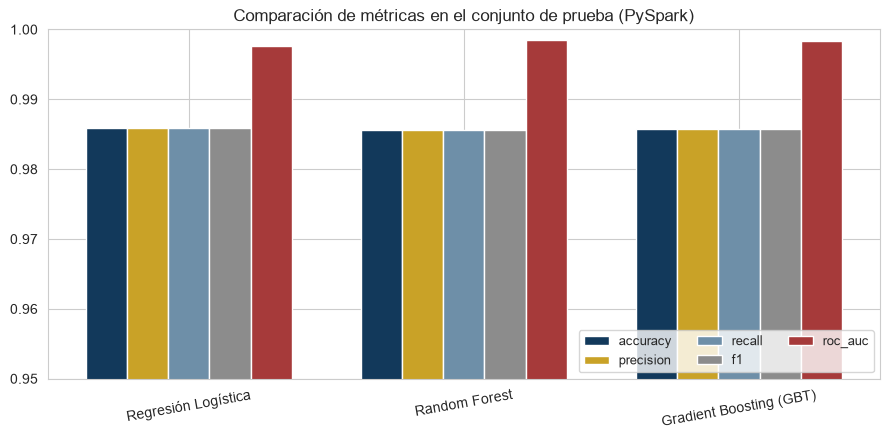

Mejor modelo (por ROC-AUC): Random Forest


In [14]:
import numpy as np
metrics_to_plot = ['accuracy_test', 'precision_test', 'recall_test', 'f1_test', 'roc_auc_test']
x = np.arange(len(results_df)); width = 0.15
colors = [NAVY, GOLD, '#6E8FA8', '#8C8C8C', '#A63A3A']
fig, ax = plt.subplots(figsize=(9, 4.5))
for i, m in enumerate(metrics_to_plot):
    ax.bar(x + i*width, results_df[m], width, label=m.replace('_test', ''), color=colors[i])
ax.set_xticks(x + width*2); ax.set_xticklabels(results_df['modelo'], rotation=10)
ax.set_ylim(0.95, 1.0); ax.legend(loc='lower right', ncol=3, fontsize=9)
ax.set_title('Comparación de métricas en el conjunto de prueba (PySpark)')
plt.tight_layout(); plt.show()

best_name = results_df.sort_values('roc_auc_test', ascending=False).iloc[0]['modelo']
print("Mejor modelo (por ROC-AUC):", best_name)

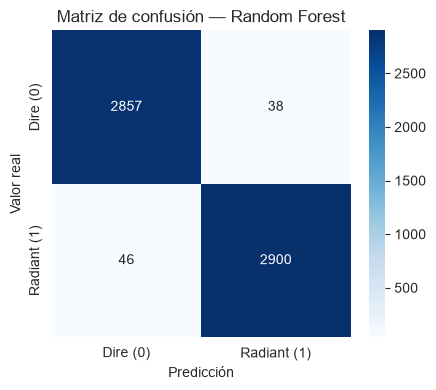

In [15]:
# Matriz de confusión del mejor modelo (calculada con Spark, graficada con pandas/seaborn)
best_model = best_models[best_name]
pred_best = best_model.transform(test)
cm_pd = pred_best.groupBy(target, "prediction").count().toPandas()
cm = cm_pd.pivot(index=target, columns="prediction", values="count").fillna(0).astype(int)
cm = cm.reindex(index=[0, 1], columns=[0, 1], fill_value=0)

fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Dire (0)', 'Radiant (1)'], yticklabels=['Dire (0)', 'Radiant (1)'])
ax.set_xlabel('Predicción'); ax.set_ylabel('Valor real')
ax.set_title(f'Matriz de confusión — {best_name}')
plt.tight_layout(); plt.show()

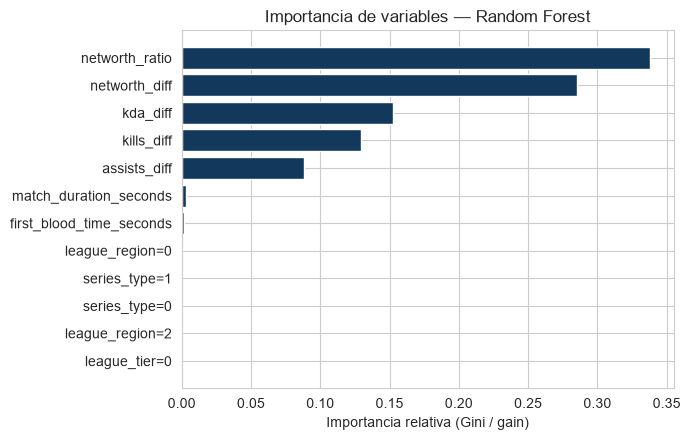

                    variable  importancia
5             networth_ratio     0.338185
4              networth_diff     0.285478
6                   kda_diff     0.152452
2                 kills_diff     0.129231
3               assists_diff     0.088284
0     match_duration_seconds     0.002874
1   first_blood_time_seconds     0.001318
13           league_region=0     0.000230
21             series_type=1     0.000218
20             series_type=0     0.000200
15           league_region=2     0.000186
7              league_tier=0     0.000174


In [16]:
# Importancia de variables nativa de los modelos de árboles de Spark ML
final_feature_names = numeric_features + []
for c in categorical_features:
    n_categories = train.select(c).distinct().count()
    final_feature_names += [f"{c}={i}" for i in range(n_categories)]

try:
    importances = best_model.stages[-1].featureImportances.toArray()
    imp_df = pd.DataFrame({
        'variable': final_feature_names[:len(importances)],
        'importancia': importances
    }).sort_values('importancia', ascending=False).head(12)

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.barh(imp_df['variable'][::-1], imp_df['importancia'][::-1], color=NAVY)
    ax.set_xlabel('Importancia relativa (Gini / gain)')
    ax.set_title(f'Importancia de variables — {best_name}')
    plt.tight_layout(); plt.show()
    print(imp_df)
except Exception as e:
    print("El mejor modelo no expone featureImportances (aplica solo a modelos de árboles):", e)

## 9. Conclusiones

- La versión en PySpark reproduce el mismo flujo de trabajo que la versión con pandas/scikit-learn,
  usando `pyspark.ml.Pipeline` con `StringIndexer`, `OneHotEncoder`, `VectorAssembler` y `StandardScaler`,
  y los tres modelos nativos de Spark MLlib: `LogisticRegression`, `RandomForestClassifier` y `GBTClassifier`.
- Los resultados son consistentes con la versión de scikit-learn: ROC-AUC cercano a 0.999 y accuracy
  de prueba cercano a 98.8% para los tres modelos, con `networth_diff` como la variable más relevante.
- **Sobre el uso de Spark aquí:** con ~194 mil filas, Spark no aporta una ventaja de rendimiento frente a
  pandas/scikit-learn en una sola máquina (de hecho, el overhead de Spark lo hace más lento en este caso).
  El valor de esta versión es demostrar el pipeline de `pyspark.ml`, que **sí escala** si el dataset creciera
  a un tamaño que no cupiera en memoria o se ejecutara en un clúster real.
- **Trabajo a futuro:** ejecutar este mismo notebook en un clúster de Spark (Databricks, EMR, etc.) con el
  dataset completo sin necesidad de tomar una muestra, aprovechando el paralelismo distribuido real.

In [17]:
spark.stop()